# 03 · Embedding Visualization & Collapse Analysis

Jointly visualise AstroDINO embeddings coloured by r_eff, axis ratio, and morphology.
Also checks for embedding collapse (cosine similarity, effective rank, NN structure).

**Sections:**
1. Filter configuration
2. Load model + compute embeddings
3. Collapse metrics (cosine similarity, variance, effective rank, NN analysis)
4. Per-class analysis
5. PCA / t-SNE / UMAP coloured by all properties

In [27]:
import os, sys, glob
import numpy as np
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from omegaconf import OmegaConf
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

PROJECT_ROOT = '/u/yacheng/projects/ssl_outthere'
sys.path.insert(0, PROJECT_ROOT)
from dinov2.eval.setup import build_model_for_eval
from encoder_image.astrodino.train.data.augmentations import ToRGB

DEG_TO_PIXEL = 3600 * 1000 / 30   # 120000
MORPH_NAMES  = {0: 'Spheroid', 1: 'Disk-dom.', 2: 'Irregular', 3: 'Bulge-dom.'}
MORPH_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda:0


## 1 · Filter Configuration
All embeddings use the same joint dataset. Change filters here and re-run.

In [28]:
MODEL_CONFIG  = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_bs128/config.yaml'
MODEL_WEIGHTS = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_bs128/eval/training_299999/teacher_checkpoint.pth'
DATA_ROOT     = '/u/yacheng/projects/ssl_outthere/images/jwst/f150w'

# ── FILTER OPTIONS ───────────────────────────────────────────────────────────
REFF_MIN_PIX       = 2.3    # min effective radius [pixels];  None = no filter
REFF_MAX_PIX       = 72   # max effective radius [pixels];  None = no filter
DELTA_THRESHOLD    = 0.5    # max delta (morph confidence);   None = no filter
AR_ERR_THRESH      = 0.05    # max axis_ratio_err (abs);       None = no filter
RE_REL_ERR_THRESH  = 0.05    # max radius_sersic_err/re;       None = no filter
EXCLUDE_IRREGULAR  = True  # True = drop morph class 2 (Irregular) from all analyses
# ────────────────────────────────────────────────────────────────────────────

N_SAMPLES   = 10000   # max samples to use; -1 = use all
BATCH_SIZE  = 64
SEED        = 42
rng = np.random.default_rng(SEED)
print(f'Filters: reff∈[{REFF_MIN_PIX},{REFF_MAX_PIX}] px  delta<{DELTA_THRESHOLD}  exclude_irr={EXCLUDE_IRREGULAR}')

Filters: reff∈[2.3,72] px  delta<0.5  exclude_irr=True


## 2 · Dataset, Model & Embeddings

In [29]:
class JointDataset(Dataset):
    """Loads samples that have valid morph, r_eff, and axis_ratio.
    Returns (image, [log10_re, axis_ratio, morph_label]).
    """
    def __init__(self, root, crop_size,
                 reff_min, reff_max, delta_threshold,
                 ar_err_thresh, re_rel_err_thresh,
                 max_samples, exclude_irregular=False, seed=42):
        self.to_rgb = ToRGB()
        self.crop   = transforms.CenterCrop(crop_size)
        _rng = np.random.default_rng(seed)

        self._files = []
        for fp in sorted(glob.glob(os.path.join(root, '*.h5'))):
            f = h5py.File(fp, 'r')
            if all(k in f for k in ['radius_sersic', 'axis_ratio', 'morph_flag_f150w']):
                self._files.append(f)
            else:
                f.close()
        print(f'Loaded {len(self._files)} files with all fields')

        self._idx = []  # (fi, li, log10_re, ar, morph)
        for fi, f in enumerate(tqdm(self._files, desc='Indexing')):
            rs    = f['radius_sersic'][:]
            ar    = f['axis_ratio'][:]
            morph = f['morph_flag_f150w'][:]
            delta = f['delta_f150w'][:] if 'delta_f150w' in f else np.full(len(rs), np.nan)
            rs_err = f['radius_sersic_err'][:] if 'radius_sersic_err' in f else None
            ar_err = f['axis_ratio_err'][:]    if 'axis_ratio_err'    in f else None

            re_pix = rs * DEG_TO_PIXEL
            vmask  = (np.isfinite(rs) & (rs > 0) &
                      np.isfinite(ar) & (ar > 0.01) & (ar < 0.99) &
                      np.isfinite(morph) & np.isfinite(delta))

            if delta_threshold is not None: vmask &= delta < delta_threshold
            if reff_min is not None:  vmask &= np.isfinite(re_pix) & (re_pix >= reff_min)
            if reff_max is not None:  vmask &= np.isfinite(re_pix) & (re_pix <= reff_max)
            if ar_err is not None and ar_err_thresh is not None:
                vmask &= np.isfinite(ar_err) & (ar_err/ar <= ar_err_thresh)
            if rs_err is not None and re_rel_err_thresh is not None:
                vmask &= np.isfinite(rs_err) & (rs_err/rs <= re_rel_err_thresh)
            if exclude_irregular:
                vmask &= (morph != 2)

            for li in np.where(vmask)[0]:
                log_r = np.log10(float(rs[li]) * DEG_TO_PIXEL)
                self._idx.append((fi, li, log_r, float(ar[li]), float(morph[li])))

        print(f'Valid samples: {len(self._idx)}' + (' (Irregular excluded)' if exclude_irregular else ''))
        if max_samples > 0 and max_samples < len(self._idx):
            chosen = _rng.choice(len(self._idx), size=max_samples, replace=False)
            self._idx = [self._idx[i] for i in chosen]
            print(f'Subsampled to {len(self._idx)}')

    def __len__(self): return len(self._idx)

    def __getitem__(self, i):
        fi, li, log_r, ar, morph = self._idx[i]
        img = self._files[fi]['image'][li].astype('float32')
        img = np.repeat(img[np.newaxis], 3, axis=0)
        t   = self.crop(torch.from_numpy(img))
        t   = torch.from_numpy(self.to_rgb(t.numpy()))
        return t, torch.tensor([log_r, ar, morph], dtype=torch.float32)

    def close(self):
        for f in self._files:
            try: f.close()
            except: pass


cfg   = OmegaConf.load(MODEL_CONFIG)
model = build_model_for_eval(cfg, pretrained_weights=MODEL_WEIGHTS)
model = model.to(DEVICE).eval()
print(f'Model loaded — crop_size={cfg.crops.global_crops_size}')

ds = JointDataset(
    DATA_ROOT, cfg.crops.global_crops_size,
    reff_min=REFF_MIN_PIX, reff_max=REFF_MAX_PIX,
    delta_threshold=DELTA_THRESHOLD,
    ar_err_thresh=AR_ERR_THRESH,
    re_rel_err_thresh=RE_REL_ERR_THRESH,
    max_samples=N_SAMPLES, exclude_irregular=EXCLUDE_IRREGULAR, seed=SEED
)
print(f'Dataset: {len(ds)} samples')

Model loaded — crop_size=72
Loaded 20 files with all fields


Indexing: 100%|██████████| 20/20 [00:00<00:00, 100.76it/s]


Valid samples: 18787 (Irregular excluded)
Subsampled to 10000
Dataset: 10000 samples


In [30]:
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
all_emb, all_lbl = [], []
with torch.no_grad():
    for imgs, lbls in tqdm(loader, desc='Embeddings'):
        imgs = imgs.to(DEVICE)
        emb  = model(imgs)
        if isinstance(emb, tuple): emb = emb[0]
        if emb.dim() > 2:          emb = emb.view(emb.size(0), -1)
        all_emb.append(emb.cpu().numpy())
        all_lbl.append(lbls.numpy())
ds.close()

embeddings = np.concatenate(all_emb)   # (N, D)
labels     = np.concatenate(all_lbl)   # (N, 3) — [log_re, ar, morph]
log_re_all = labels[:, 0]
ar_all     = labels[:, 1]
morph_all  = labels[:, 2].astype(int)

print(f'Embeddings: {embeddings.shape}')
print(f'r_eff range: [{10**log_re_all.min():.2f}, {10**log_re_all.max():.2f}] px')
print(f'axis_ratio range: [{ar_all.min():.3f}, {ar_all.max():.3f}]')
unique, counts = np.unique(morph_all, return_counts=True)
print('Morph:', {int(u): int(c) for u, c in zip(unique, counts)})

Embeddings: 100%|██████████| 157/157 [00:13<00:00, 11.84it/s]

Embeddings: (10000, 512)
r_eff range: [2.30, 71.62] px
axis_ratio range: [0.044, 0.989]
Morph: {0: 2823, 1: 4754, 3: 2423}


## 3 · Collapse Metrics

Checks whether all embeddings have collapsed to a single point / low-dimensional subspace.

In [31]:
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors

# L2-normalise for cosine similarity analysis
emb_norm = normalize(embeddings, norm='l2')

# ── Sample for pairwise analysis (keeps memory manageable) ──────────────────
N_COLLAPSE = min(2000, len(embeddings))
idx_c = rng.choice(len(embeddings), size=N_COLLAPSE, replace=False)
emb_c = emb_norm[idx_c]

# 1. Pairwise cosine similarity
idx1 = rng.integers(0, N_COLLAPSE, size=50000)
idx2 = rng.integers(0, N_COLLAPSE, size=50000)
cos_sim = (emb_c[idx1] * emb_c[idx2]).sum(axis=1)

# 2. Per-dimension variance
dim_var = emb_c.var(axis=0)
D       = embeddings.shape[1]
expected_var = 1.0 / D

# 3. Effective rank (participation ratio)
cov = np.cov(emb_c.T)
evals = np.linalg.eigvalsh(cov)
evals = np.maximum(evals, 0)[::-1]
participation_ratio = (evals.sum())**2 / (evals**2).sum()
probs = evals / evals.sum()
probs = probs[probs > 0]
effective_rank = np.exp(-np.sum(probs * np.log(probs)))
cum_var = np.cumsum(evals) / evals.sum()
n_dims_90 = int(np.searchsorted(cum_var, 0.90)) + 1

# 4. Nearest-neighbour gap ratio
knn = NearestNeighbors(n_neighbors=11, algorithm='auto', metric='cosine').fit(emb_c)
dists, _ = knn.kneighbors(emb_c)
d1 = dists[:, 1]   # nearest neighbour
d10 = dists[:, 10]  # 10th neighbour
gap_ratio = (d10 - d1) / (d10 + 1e-10)

print('=== Collapse Metrics ===')
print(f'  Pairwise cos. similarity:  mean={cos_sim.mean():.4f}  std={cos_sim.std():.4f}')
print(f'  Pairs with cos_sim > 0.9:  {(cos_sim > 0.9).mean()*100:.3f}%  (collapse if >> 0)')
print(f'  Per-dim variance:           mean={dim_var.mean():.6f}  (expected ~{expected_var:.6f})')
print(f'  Dims with var < 0.1×expected: {(dim_var < 0.1*expected_var).sum()}/{D}')
print(f'  Participation ratio:        {participation_ratio:.1f}/{D}')
print(f'  Effective rank (entropy):   {effective_rank:.1f}/{D}')
print(f'  Dims for 90% variance:      {n_dims_90}')
print(f'  NN gap ratio:               mean={gap_ratio.mean():.4f}  (random baseline ~0.015)')

=== Collapse Metrics ===
  Pairwise cos. similarity:  mean=0.1116  std=0.1477
  Pairs with cos_sim > 0.9:  0.088%  (collapse if >> 0)
  Per-dim variance:           mean=0.001736  (expected ~0.001953)
  Dims with var < 0.1×expected: 69/512
  Participation ratio:        40.0/512
  Effective rank (entropy):   74.4/512
  Dims for 90% variance:      81
  NN gap ratio:               mean=0.4429  (random baseline ~0.015)


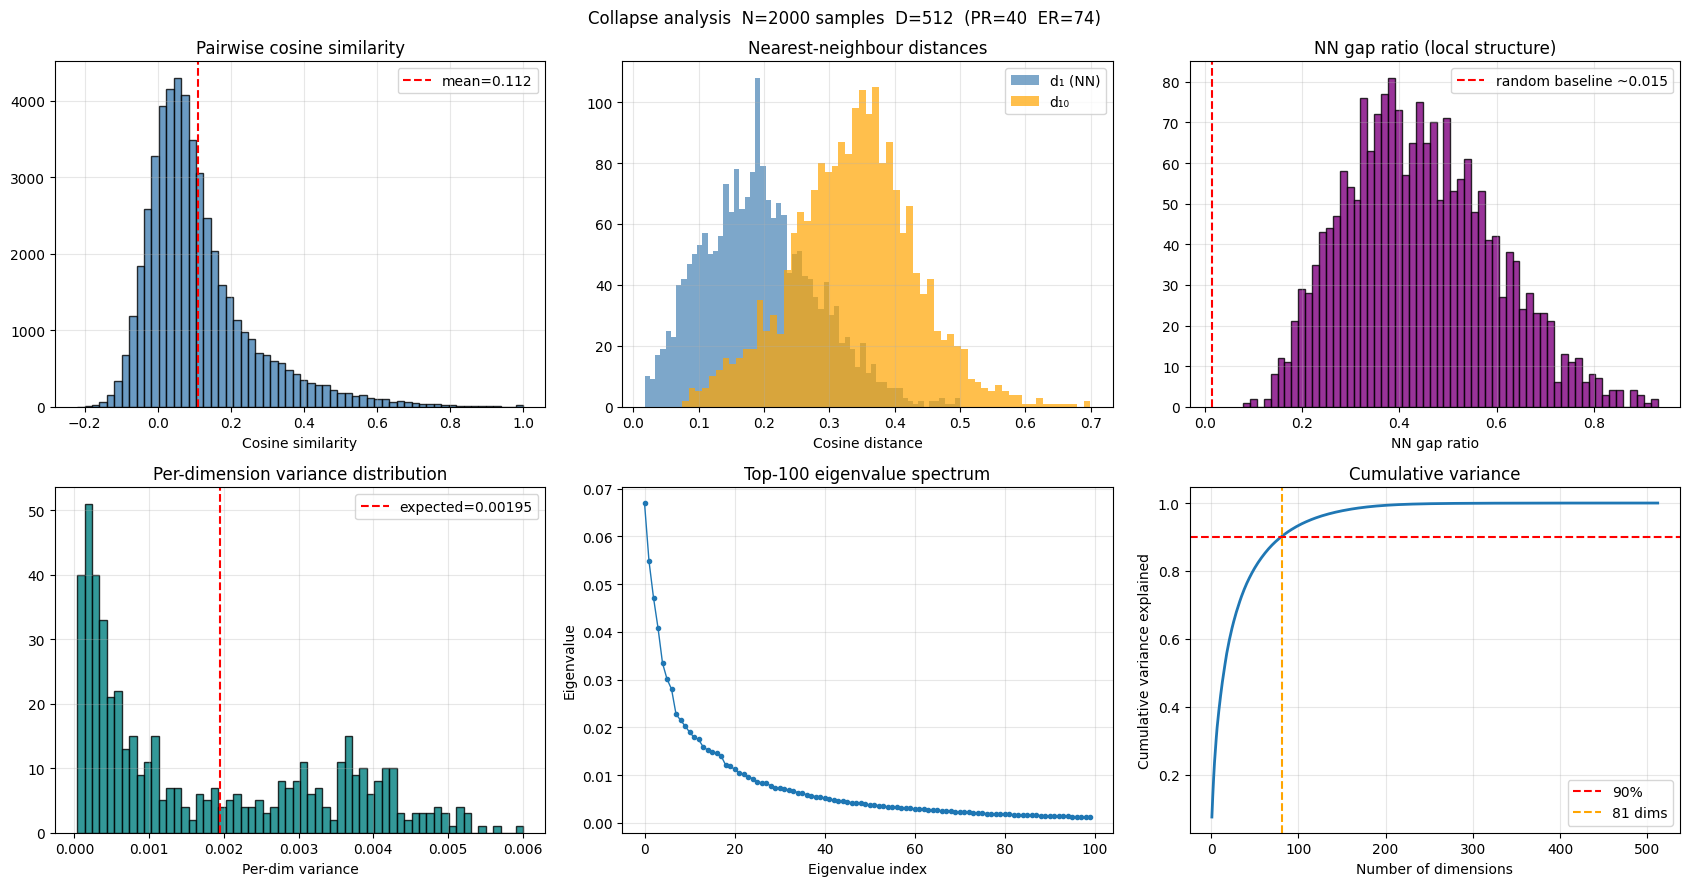

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

ax = axes[0, 0]
ax.hist(cos_sim, bins=60, edgecolor='black', alpha=0.8, color='steelblue')
ax.axvline(cos_sim.mean(), color='red', linestyle='--', label=f'mean={cos_sim.mean():.3f}')
ax.set_xlabel('Cosine similarity')
ax.set_title('Pairwise cosine similarity')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.hist(d1, bins=60, alpha=0.7, label='d₁ (NN)', color='steelblue')
ax.hist(d10, bins=60, alpha=0.7, label='d₁₀', color='orange')
ax.set_xlabel('Cosine distance')
ax.set_title('Nearest-neighbour distances')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.hist(gap_ratio, bins=60, edgecolor='black', alpha=0.8, color='purple')
ax.axvline(0.015, color='red', linestyle='--', label='random baseline ~0.015')
ax.set_xlabel('NN gap ratio')
ax.set_title('NN gap ratio (local structure)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.hist(dim_var, bins=60, edgecolor='black', alpha=0.8, color='teal')
ax.axvline(expected_var, color='red', linestyle='--', label=f'expected={expected_var:.5f}')
ax.set_xlabel('Per-dim variance')
ax.set_title('Per-dimension variance distribution')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(evals[:100], marker='o', markersize=3, linewidth=1)
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('Eigenvalue')
ax.set_title('Top-100 eigenvalue spectrum')
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(np.arange(1, len(cum_var)+1), cum_var, linewidth=2)
ax.axhline(0.90, color='red', linestyle='--', label='90%')
ax.axvline(n_dims_90, color='orange', linestyle='--', label=f'{n_dims_90} dims')
ax.set_xlabel('Number of dimensions')
ax.set_ylabel('Cumulative variance explained')
ax.set_title('Cumulative variance')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Collapse analysis  N={N_COLLAPSE} samples  D={D}  '
             f'(PR={participation_ratio:.0f}  ER={effective_rank:.0f})',
             fontsize=12)
plt.tight_layout()
plt.show()

## 4 · Per-Class Embedding Analysis

Intra- vs inter-class cosine similarity and NN purity by morphology class.

In [33]:
classes = sorted(np.unique(morph_all))
N_CLS_SAMPLE = min(300, min((morph_all == c).sum() for c in classes))

intra_sims, inter_sims = {}, {}
nn_purity = {}
knn_cls = NearestNeighbors(n_neighbors=11, algorithm='auto', metric='cosine').fit(emb_norm)
_, nn_idx_all = knn_cls.kneighbors(emb_norm)

for c in classes:
    c_mask = morph_all == c
    c_emb  = emb_norm[c_mask]
    nc     = min(N_CLS_SAMPLE, len(c_emb))
    sub    = rng.choice(len(c_emb), size=nc, replace=False)

    # Intra-class cosine sim
    i1 = rng.integers(0, nc, size=5000)
    i2 = rng.integers(0, nc, size=5000)
    intra_sims[c] = (c_emb[sub[i1]] * c_emb[sub[i2]]).sum(axis=1)

    # Inter-class cosine sim (vs all other classes)
    other_emb = emb_norm[~c_mask]
    o_sub = rng.choice(len(other_emb), size=min(5000, len(other_emb)), replace=False)
    i_c = rng.integers(0, nc, size=5000)
    i_o = rng.choice(len(o_sub), size=5000)
    inter_sims[c] = (c_emb[sub[i_c]] * other_emb[o_sub[i_o]]).sum(axis=1)

    # NN purity: fraction of k=10 nearest neighbours with same class
    global_idx_c = np.where(c_mask)[0]
    purity_vals = []
    for gi in global_idx_c[:200]:
        nn_labels = morph_all[nn_idx_all[gi, 1:]]   # skip self
        purity_vals.append((nn_labels == c).mean())
    nn_purity[c] = np.mean(purity_vals)

print(f"{'Class':<15} {'Intra-mean':>12} {'Inter-mean':>12} {'NN purity k=10':>15} {'Lift over rand':>15}")
print('-' * 72)
for c in classes:
    rand_base = (morph_all == c).mean()
    lift = nn_purity[c] / rand_base if rand_base > 0 else 0
    print(f'{MORPH_NAMES.get(c, c):<15} {intra_sims[c].mean():>12.4f} '
          f'{inter_sims[c].mean():>12.4f} {nn_purity[c]*100:>14.1f}% '
          f'{lift:>14.2f}x')

Class             Intra-mean   Inter-mean  NN purity k=10  Lift over rand
------------------------------------------------------------------------
Spheroid              0.1598       0.0878           77.1%           2.73x
Disk-dom.             0.1477       0.0847           84.8%           1.78x
Bulge-dom.            0.1718       0.1070           52.8%           2.18x


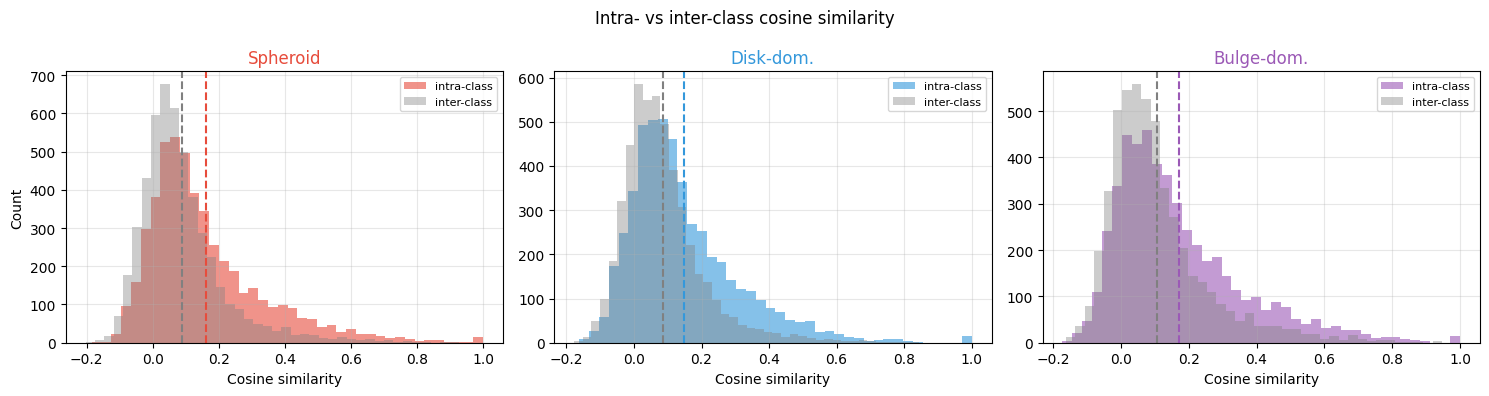

In [34]:
fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 4), sharey=False)
for ax, c in zip(axes, classes):
    col = MORPH_COLORS[c]
    ax.hist(intra_sims[c], bins=40, alpha=0.6, label='intra-class', color=col)
    ax.hist(inter_sims[c], bins=40, alpha=0.4, label='inter-class', color='gray')
    ax.axvline(intra_sims[c].mean(), color=col,   linestyle='--', linewidth=1.5)
    ax.axvline(inter_sims[c].mean(), color='gray', linestyle='--', linewidth=1.5)
    ax.set_title(MORPH_NAMES.get(c, c), color=col)
    ax.set_xlabel('Cosine similarity')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Count')
plt.suptitle('Intra- vs inter-class cosine similarity', fontsize=12)
plt.tight_layout()
plt.show()

## 5 · PCA / t-SNE / UMAP

3×3 grid: each row is a dimensionality reduction; each column is a colour variable.

In [35]:
N_VIS = min(10000, len(embeddings))
vis_idx = rng.choice(len(embeddings), size=N_VIS, replace=False)
emb_vis    = embeddings[vis_idx]
log_re_vis = log_re_all[vis_idx]
ar_vis     = ar_all[vis_idx]
morph_vis  = morph_all[vis_idx]

print('Running PCA...')
pca     = PCA(n_components=50, random_state=SEED)
emb_pca = pca.fit_transform(emb_vis)
print(f'  Explained variance (top 50): {pca.explained_variance_ratio_.sum():.2%}')

print('Running t-SNE...')
tsne     = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
emb_tsne = tsne.fit_transform(emb_pca)

print('Running UMAP...')
reducer  = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEED)
emb_umap = reducer.fit_transform(emb_pca)
print('Done.')

Running PCA...
  Explained variance (top 50): 80.36%
Running t-SNE...
Running UMAP...


/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


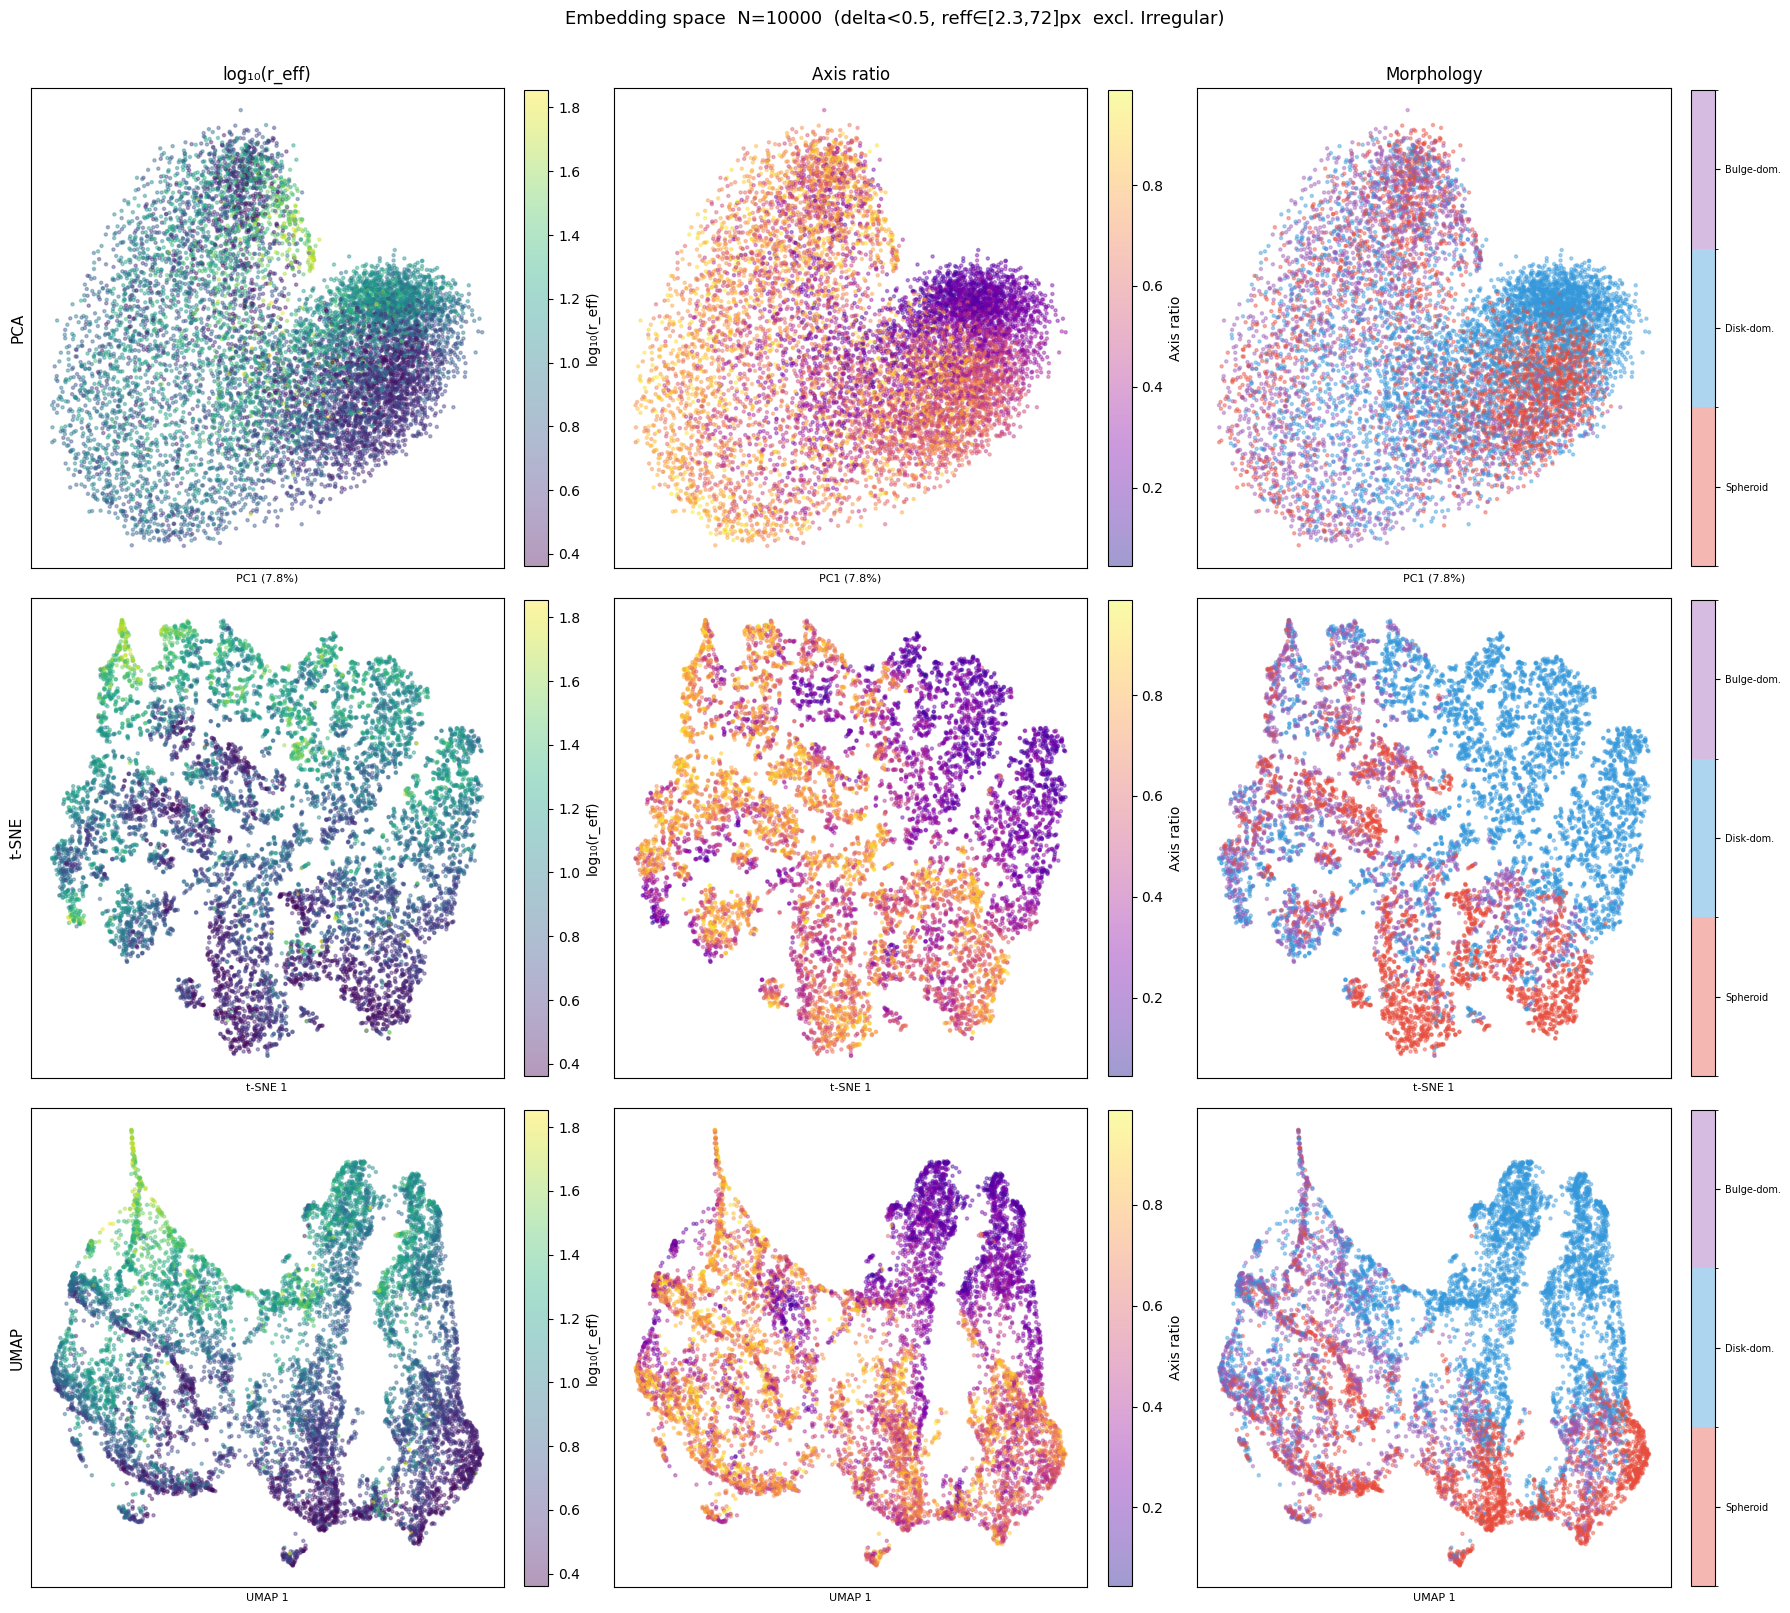

In [36]:
# Build colormap that handles only the classes actually present
# (e.g. [0,1,3] when EXCLUDE_IRREGULAR=True, not assuming contiguous 0-3)
present_classes = sorted(np.unique(morph_vis))
cls_colors = [MORPH_COLORS[c] for c in present_classes]
morph_cmap = ListedColormap(cls_colors)
morph_norm = BoundaryNorm(np.arange(-0.5, len(present_classes) + 0.5), morph_cmap.N)
# Remap morph labels to contiguous 0..N-1 for the colormap
cls_remap = {c: i for i, c in enumerate(present_classes)}
morph_vis_mapped = np.array([cls_remap[v] for v in morph_vis])

dim_methods = [
    ('PCA',    emb_pca,  f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'),
    ('t-SNE',  emb_tsne, 't-SNE 1', 't-SNE 2'),
    ('UMAP',   emb_umap, 'UMAP 1',  'UMAP 2'),
]
color_cols = [
    ('log₁₀(r_eff)', log_re_vis,        'viridis', False),
    ('Axis ratio',   ar_vis,             'plasma',  False),
    ('Morphology',   morph_vis_mapped,   morph_cmap, True),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 16))

for row, (method, emb, xlabel, ylabel) in enumerate(dim_methods):
    for col, (clabel, cvals, cmap, is_disc) in enumerate(color_cols):
        ax = axes[row, col]
        if is_disc:
            sc = ax.scatter(emb[:, 0], emb[:, 1], c=cvals, cmap=cmap,
                            norm=morph_norm, s=5, alpha=0.4)
            cb = plt.colorbar(sc, ax=ax, ticks=list(range(len(present_classes))),
                              fraction=0.046, pad=0.04)
            cb.ax.set_yticklabels([MORPH_NAMES[c] for c in present_classes], fontsize=7)
        else:
            sc = ax.scatter(emb[:, 0], emb[:, 1], c=cvals, cmap=cmap, s=5, alpha=0.4)
            plt.colorbar(sc, ax=ax, label=clabel, fraction=0.046, pad=0.04)
        if row == 0:
            ax.set_title(clabel, fontsize=12)
        if col == 0:
            ax.set_ylabel(method, fontsize=11)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

irr_note = '  excl. Irregular' if EXCLUDE_IRREGULAR else ''
plt.suptitle(
    f'Embedding space  N={N_VIS}  '
    f'(delta<{DELTA_THRESHOLD}, reff∈[{REFF_MIN_PIX},{REFF_MAX_PIX}]px{irr_note})',
    fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

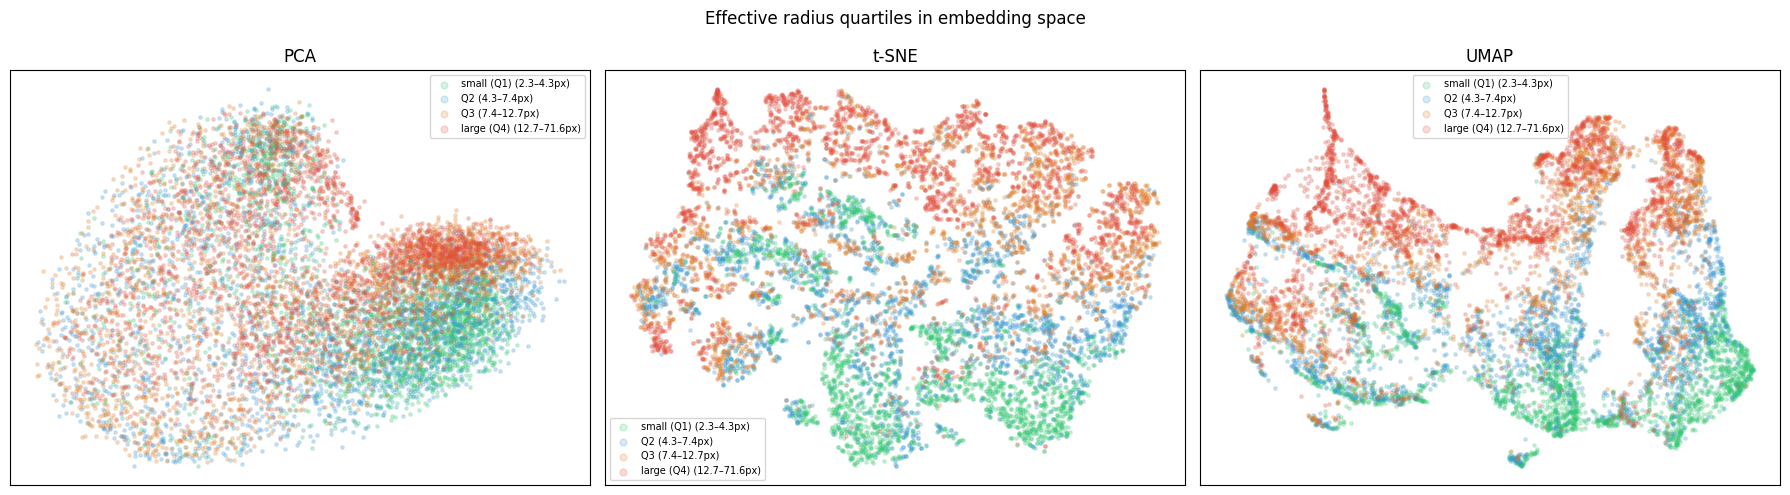

In [37]:
# ── Highlight r_eff slices in embedding space ──────────────────────────────
# Shows where galaxies of different sizes land in UMAP
re_bins   = np.percentile(log_re_vis, [0, 25, 50, 75, 100])
bin_names = ['small (Q1)', 'Q2', 'Q3', 'large (Q4)']
bin_colors= ['#2ECC71', '#3498DB', '#E67E22', '#E74C3C']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
method_embs = [emb_pca, emb_tsne, emb_umap]
method_names = ['PCA', 't-SNE', 'UMAP']

for ax, emb, mname in zip(axes, method_embs, method_names):
    ax.scatter(emb[:, 0], emb[:, 1], s=3, c='lightgray', alpha=0.1)
    for qi, (lo, hi, bname, bc) in enumerate(zip(re_bins[:-1], re_bins[1:], bin_names, bin_colors)):
        mask = (log_re_vis >= lo) & (log_re_vis < hi)
        label = f'{bname} ({10**lo:.1f}–{10**hi:.1f}px)'
        ax.scatter(emb[mask, 0], emb[mask, 1], s=6, alpha=0.2, c=bc, label=label)
    ax.set_title(mname)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=7, markerscale=2)

plt.suptitle('Effective radius quartiles in embedding space', fontsize=12)
plt.tight_layout()
plt.show()